# 01 · Exploración de bases de datos y selección

**Evento evaluativo 2 – Análisis de Datos (ITM, 2026-2)**
**Fase 1 del proyecto.** Responsable del módulo: Juana.

El enunciado pide explorar al menos **3 bases de datos de al menos 2 tipos distintos** y escoger una con criterios objetivos. Exploramos tres bases de **tres tipos**:

| # | Base | Tipo de dato |
|---|------|--------------|
| A | Hotel Booking Demand | Tabular |
| B | SMS Spam Collection | Texto |
| C | Fashion-MNIST | Imágenes |

Para cada una documentamos: fuente y tipo de fuente (primaria, secundaria o terciaria), características básicas (registros, atributos, tamaño), nivel de documentación y posibles aplicaciones. Al final comparamos las tres con una matriz de decisión ponderada.

> Las tres bases se leen directamente desde una URL pública, así que el notebook corre en Google Colab sin subir archivos.

In [1]:
import gzip
import io
import time
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
AZUL, NARANJA, GRIS = "#0072B2", "#D55E00", "#6E6E6E"


def descargar(url):
    """Descarga una URL y devuelve (bytes, segundos, tamaño en MB)."""
    t0 = time.time()
    with urllib.request.urlopen(url) as r:
        datos = r.read()
    return datos, time.time() - t0, len(datos) / 1e6


def ficha(nombre, tipo, registros, atributos, mb_disco, mb_memoria, pct_completo, segundos):
    """Fila con las características básicas medidas (no estimadas) de una base."""
    return {"Base": nombre, "Tipo": tipo, "Registros": registros, "Atributos": atributos,
            "Tamaño en disco (MB)": round(mb_disco, 2), "Memoria en pandas/numpy (MB)": round(mb_memoria, 1),
            "% celdas completas": round(pct_completo, 2), "Carga (s)": round(segundos, 1)}


fichas = []

## A. Hotel Booking Demand (tabular)

- **Origen:** Antonio, N., de Almeida, A. y Nunes, L. (2019). *Hotel booking demand datasets*. Data in Brief, 22, 41–49.
- **Qué contiene:** reservas de dos hoteles de Portugal (un hotel de ciudad en Lisboa y un resort en el Algarve) con llegada entre julio de 2015 y agosto de 2017. Cada fila es una reserva, e incluye si terminó cancelada.
- **Tipo de fuente:** los datos nacen en el sistema de gestión (PMS) de los hoteles, así que para los hoteles son una **fuente primaria**. Para nosotros es una **fuente secundaria**: recibimos lo que los autores extrajeron, anonimizaron y publicaron. El repositorio desde donde lo descargamos (TidyTuesday en GitHub, espejo del mismo archivo que está en Kaggle) cumple el papel de **fuente terciaria**: no produce el dato, solo nos ayuda a encontrarlo.

In [2]:
URL_HOTEL = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"

crudo, seg, mb = descargar(URL_HOTEL)
hotel = pd.read_csv(io.BytesIO(crudo))

print("Dimensiones:", hotel.shape)
hotel.head()

Dimensiones: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
# Tipos de variable: ¿qué tan variada es la base?
es_num = hotel.dtypes.apply(pd.api.types.is_numeric_dtype)
print("Variables numéricas  :", int(es_num.sum()))
print("Variables de texto   :", int((~es_num).sum()))

faltantes = hotel.isna().sum()
print("\nVariables con valores faltantes:")
print(faltantes[faltantes > 0].to_string())

completo_hotel = 100 * (1 - hotel.isna().sum().sum() / hotel.size)
print(f"\nCeldas completas: {completo_hotel:.2f} %")
print(f"Filas exactamente repetidas: {hotel.duplicated().sum():,}")

fichas.append(ficha("A. Hotel Booking Demand", "Tabular", len(hotel), hotel.shape[1], mb,
                    hotel.memory_usage(deep=True).sum() / 1e6, completo_hotel, seg))

Variables numéricas  : 20
Variables de texto   : 12

Variables con valores faltantes:
children         4
country        488
agent        16340
company     112593

Celdas completas: 96.61 %


Filas exactamente repetidas: 31,994


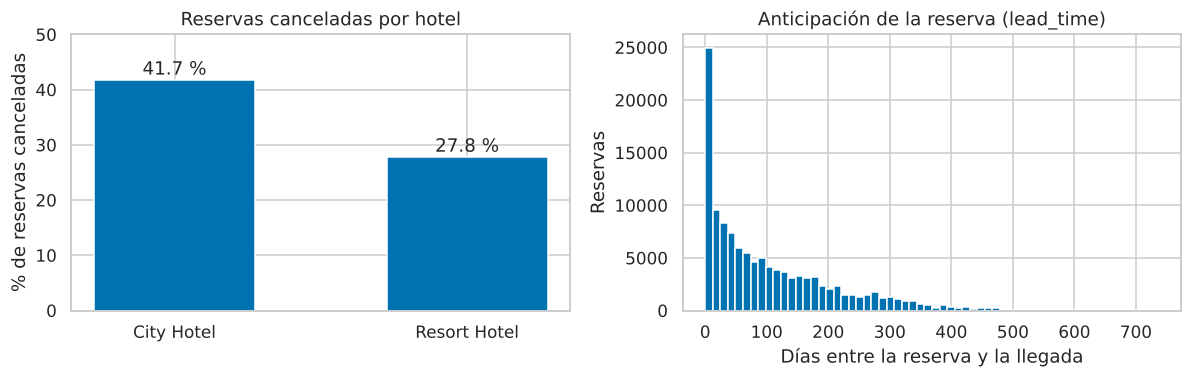

In [4]:
# Primera mirada: la variable que nos interesaría explicar
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

tasa = hotel.groupby("hotel")["is_canceled"].mean().mul(100)
ax[0].bar(tasa.index, tasa.values, color=AZUL, width=0.55)
for i, v in enumerate(tasa.values):
    ax[0].text(i, v + 1, f"{v:.1f} %", ha="center")
ax[0].set(title="Reservas canceladas por hotel", ylabel="% de reservas canceladas", ylim=(0, 50))

ax[1].hist(hotel["lead_time"], bins=60, color=AZUL)
ax[1].set(title="Anticipación de la reserva (lead_time)", xlabel="Días entre la reserva y la llegada", ylabel="Reservas")
plt.tight_layout()
plt.show()

**Lo que vemos en A.** Esta base tiene 119.390 reservas y 32 columnas. Nos gustó que tiene de todo: variables numéricas (días de anticipación, tarifa, noches), categóricas (segmento, tipo de depósito, país) y fechas. También vimos que no viene limpia: hay 4 columnas con datos faltantes (`company` está casi vacía y a `agent` le falta el 13,7 %) y más de 31 mil filas repetidas. Al principio eso nos pareció un punto en contra, pero después pensamos que para un EDA es mejor, porque hay cosas que revisar y decisiones que tomar. El artículo de los autores explica qué significa cada variable.

**Para qué podría servir:** predecir cancelaciones, decidir políticas de depósito, pronosticar la demanda o segmentar clientes.

## B. SMS Spam Collection (texto)

- **Origen:** Almeida, T. A., Gómez Hidalgo, J. M. y Yamakami, A. (2011). *Contributions to the study of SMS spam filtering*. Publicada en el UCI Machine Learning Repository.
- **Qué contiene:** mensajes SMS en inglés etiquetados como `ham` (legítimo) o `spam`.
- **Tipo de fuente:** los autores no recolectaron los mensajes: los **compilaron** de corpus anteriores (Grumbletext, NUS SMS Corpus y una tesis doctoral). Es una **fuente secundaria** construida sobre fuentes primarias; UCI y los espejos en GitHub son la **fuente terciaria**.

In [5]:
URL_SMS = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

crudo, seg, mb = descargar(URL_SMS)
sms = pd.read_csv(io.BytesIO(crudo), sep="\t", header=None, names=["etiqueta", "mensaje"])

print("Dimensiones:", sms.shape)
print("Faltantes:", int(sms.isna().sum().sum()), "| Mensajes repetidos:", int(sms.duplicated().sum()))
print(sms["etiqueta"].value_counts(normalize=True).mul(100).round(1).to_string())

fichas.append(ficha("B. SMS Spam Collection", "Texto", len(sms), sms.shape[1], mb,
                    sms.memory_usage(deep=True).sum() / 1e6, 100 * (1 - sms.isna().sum().sum() / sms.size), seg))
sms.head()

Dimensiones: (5572, 2)
Faltantes: 0 | Mensajes repetidos: 403
etiqueta
ham     86.6
spam    13.4


,etiqueta,mensaje
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


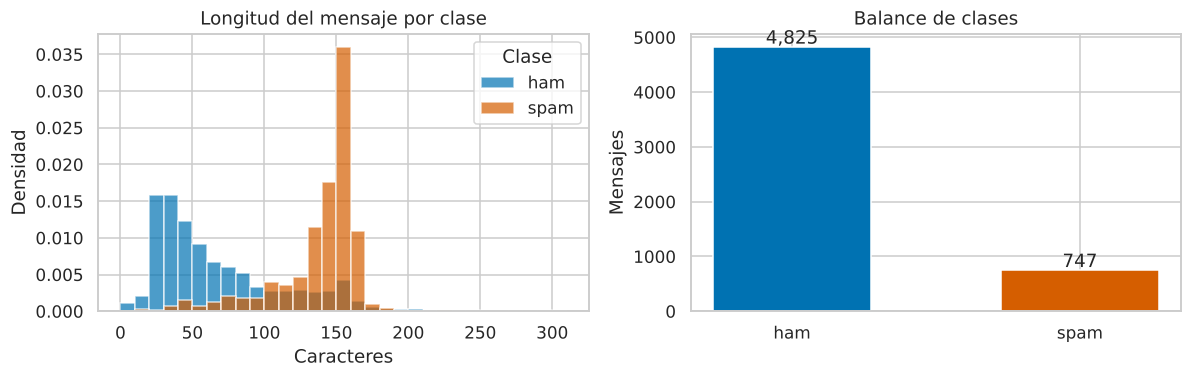

           count   mean   std   min    25%    50%    75%    max
etiqueta                                                       
ham       4825.0   71.5  58.4   2.0   33.0   52.0   93.0  910.0
spam       747.0  138.7  28.9  13.0  133.0  149.0  157.0  223.0


In [6]:
# En texto no hay columnas numéricas: hay que derivarlas. La más simple es la longitud del mensaje.
sms["longitud"] = sms["mensaje"].str.len()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for etiqueta, color in [("ham", AZUL), ("spam", NARANJA)]:
    ax[0].hist(sms.loc[sms["etiqueta"] == etiqueta, "longitud"], bins=np.arange(0, 320, 10),
               alpha=0.7, color=color, label=etiqueta, density=True)
ax[0].set(title="Longitud del mensaje por clase", xlabel="Caracteres", ylabel="Densidad")
ax[0].legend(title="Clase")

conteo = sms["etiqueta"].value_counts()
ax[1].bar(conteo.index, conteo.values, color=[AZUL, NARANJA], width=0.55)
for i, v in enumerate(conteo.values):
    ax[1].text(i, v + 60, f"{v:,}", ha="center")
ax[1].set(title="Balance de clases", ylabel="Mensajes")
plt.tight_layout()
plt.show()

print(sms.groupby("etiqueta")["longitud"].describe().round(1).to_string())

**Lo que vemos en B.** Son 5.572 mensajes y solo 2 columnas: la etiqueta y el texto. No tiene faltantes. La mayoría de los mensajes son legítimos (87 %) y notamos que los de spam son más largos. El problema que le vimos es que con texto no podemos hacer directamente lo que pide el proyecto (correlaciones, atípicos, PCA): primero habría que convertir el texto en números con técnicas como TF-IDF, que todavía no hemos visto en el curso. Nos quedaría un EDA muy corto, casi solo con la longitud de los mensajes.

**Para qué podría servir:** filtros de spam y clasificación de texto.

## C. Fashion-MNIST (imágenes)

- **Origen:** Xiao, H., Rasul, K. y Vollgraf, R. (2017). *Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms*. Zalando Research.
- **Qué contiene:** fotos de prendas del catálogo de Zalando convertidas a escala de grises de 28×28 píxeles, en 10 clases. La base completa tiene 70.000 imágenes (60.000 de entrenamiento y 10.000 de prueba). Aquí exploramos la **partición de prueba (10.000)**, suficiente para caracterizarla.
- **Tipo de fuente:** Zalando generó las imágenes a partir de su propio catálogo: para ellos es **fuente primaria**. Para nosotros es **secundaria**, porque ya vienen recortadas, reescaladas y etiquetadas con sus criterios. El repositorio de GitHub es la vía de acceso.

In [7]:
BASE_FM = "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"
CLASES = ["Camiseta", "Pantalón", "Suéter", "Vestido", "Abrigo", "Sandalia", "Camisa", "Tenis", "Bolso", "Botín"]

crudo_x, seg_x, mb_x = descargar(BASE_FM + "t10k-images-idx3-ubyte.gz")
crudo_y, seg_y, mb_y = descargar(BASE_FM + "t10k-labels-idx1-ubyte.gz")

# El formato IDX no es un CSV: es binario con un encabezado (16 bytes en imágenes, 8 en etiquetas).
X = np.frombuffer(gzip.decompress(crudo_x), dtype=np.uint8, offset=16).reshape(-1, 28, 28)
y = np.frombuffer(gzip.decompress(crudo_y), dtype=np.uint8, offset=8)

print("Imágenes:", X.shape, "| Etiquetas:", y.shape)
print("Rango de intensidades:", X.min(), "a", X.max())
print("Imágenes por clase:", dict(zip(CLASES, np.bincount(y).tolist())))

fichas.append(ficha("C. Fashion-MNIST (prueba)", "Imágenes", len(X), 28 * 28, mb_x + mb_y,
                    (X.nbytes + y.nbytes) / 1e6, 100.0, seg_x + seg_y))

Imágenes: (10000, 28, 28) | Etiquetas: (10000,)
Rango de intensidades: 0 a 255
Imágenes por clase: {'Camiseta': 1000, 'Pantalón': 1000, 'Suéter': 1000, 'Vestido': 1000, 'Abrigo': 1000, 'Sandalia': 1000, 'Camisa': 1000, 'Tenis': 1000, 'Bolso': 1000, 'Botín': 1000}


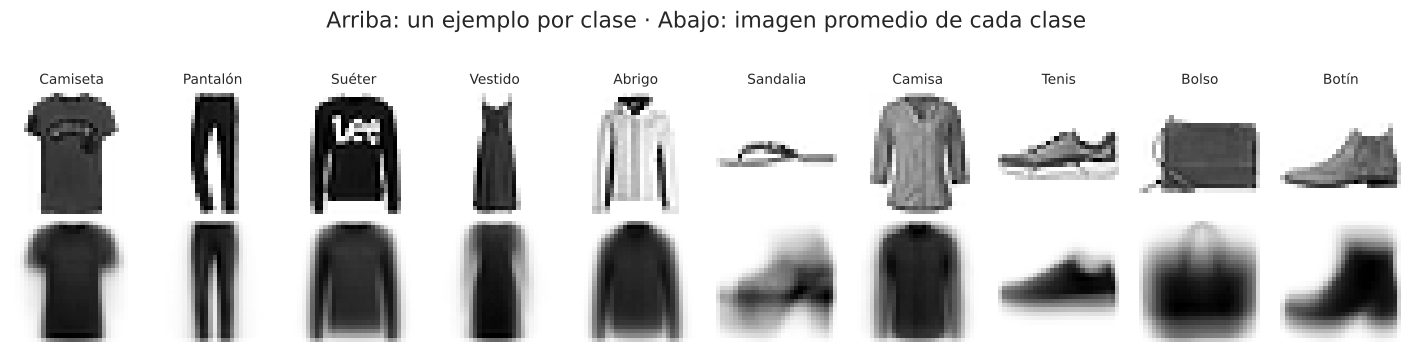

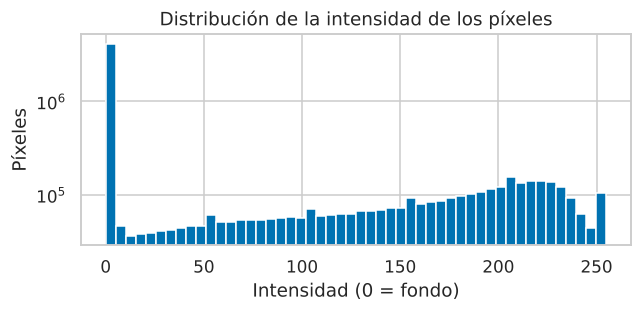

Píxeles en cero (fondo): 50.0 %


In [8]:
fig, ax = plt.subplots(2, 10, figsize=(13, 3.2))
for c in range(10):
    ax[0, c].imshow(X[y == c][0], cmap="gray_r")
    ax[0, c].set_title(CLASES[c], fontsize=9)
    ax[1, c].imshow(X[y == c].mean(axis=0), cmap="gray_r")   # imagen promedio de la clase
    for fila in (0, 1):
        ax[fila, c].axis("off")
fig.suptitle("Arriba: un ejemplo por clase · Abajo: imagen promedio de cada clase", y=1.02)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(X.ravel(), bins=50, color=AZUL)
ax.set(title="Distribución de la intensidad de los píxeles", xlabel="Intensidad (0 = fondo)", ylabel="Píxeles")
ax.set_yscale("log")
plt.tight_layout()
plt.show()
print(f"Píxeles en cero (fondo): {100 * (X == 0).mean():.1f} %")

**Lo que vemos en C.** Cada imagen tiene 784 columnas, que son los píxeles, todos con valores entre 0 y 255. Hay exactamente 1.000 imágenes por clase y no hay faltantes, o sea que la base ya viene muy organizada. La mitad de los píxeles son fondo (valor 0). Creemos que serviría mucho para practicar PCA, pero no tiene variables categóricas para codificar ni datos faltantes para tratar, y analizar un píxel por separado no nos dice nada. Además el archivo viene en un formato binario (IDX) que toca leer a mano.

**Para qué podría servir:** clasificación de imágenes y reducción de dimensionalidad.

## Comparación y selección

### Características medidas

In [9]:
tabla = pd.DataFrame(fichas).set_index("Base")
tabla

,Tipo,Registros,Atributos,Tamaño en disco (MB),Memoria en pandas/numpy (MB),% celdas completas,Carga (s)
Base,,,,,,,
A. Hotel Booking Demand,Tabular,119390,32,16.86,98.5,96.61,0.8
B. SMS Spam Collection,Texto,5572,2,0.48,1.1,100.00,0.3
C. Fashion-MNIST (prueba),Imágenes,10000,784,4.43,7.8,100.00,0.5


### Matriz de decisión

Usamos los cuatro criterios que propone el enunciado. Para que la selección sea objetiva, cada criterio tiene **un peso** y **una regla de calificación** de 1 a 5 definida antes de calificar:

| Criterio | Peso | Cómo se califica |
|---|---|---|
| **Completitud** | 20 % | Porcentaje de celdas con dato. 5 = 100 %; 4 = entre 95 % y 99,9 %; 3 = entre 85 % y 95 %. |
| **Relevancia** | 30 % | Cuántas de las tareas que exige el proyecto se pueden hacer **directamente** sobre la base: faltantes, atípicos, univariado numérico y categórico, multivariado, hipótesis, codificación, escalado y PCA (8 tareas). 5 = las 8; 4 = 6 o 7; 3 = 4 o 5; 2 = 3 o menos. |
| **Documentación** | 25 % | 5 = artículo publicado **y** diccionario de variables; 4 = artículo o ficha del repositorio; 3 = solo descripción informal. |
| **Manejabilidad** | 25 % | Tamaño y formato. 5 = menos de 5 MB en formato tabular; 4 = carga en Colab en segundos, pero pesa más o requiere lectura especial; 3 = exige muestreo o hardware adicional. |

El peso más alto es **relevancia** porque el objetivo del proyecto es practicar el EDA completo: una base perfecta pero sin nada que diagnosticar no nos deja mostrar lo aprendido.

In [10]:
pesos = {"Completitud": 0.20, "Relevancia": 0.30, "Documentación": 0.25, "Manejabilidad": 0.25}

# Tareas del proyecto que cada base permite hacer directamente (sin transformar su naturaleza)
tareas = ["Faltantes", "Atípicos", "Univariado numérico", "Univariado categórico",
          "Multivariado", "Hipótesis", "Codificación", "Escalado y PCA"]
cobertura = pd.DataFrame(
    {"A. Hotel": [1, 1, 1, 1, 1, 1, 1, 1],
     "B. SMS":   [0, 0, 0, 1, 0, 1, 1, 0],
     "C. Fashion-MNIST": [0, 1, 1, 0, 1, 0, 0, 1]},
    index=tareas)
print("Tareas del proyecto que cubre cada base:")
print(cobertura.replace({1: "sí", 0: "no"}).to_string())
print("\nTotal:", cobertura.sum().to_dict())

puntajes = pd.DataFrame(
    {"Completitud":   [4, 5, 5],
     "Relevancia":    [5, 2, 3],
     "Documentación": [5, 4, 5],
     "Manejabilidad": [4, 5, 4]},
    index=["A. Hotel Booking Demand", "B. SMS Spam Collection", "C. Fashion-MNIST"])

puntajes["Total ponderado"] = sum(puntajes[c] * p for c, p in pesos.items()).round(2)
puntajes.sort_values("Total ponderado", ascending=False)

Tareas del proyecto que cubre cada base:
                      A. Hotel B. SMS C. Fashion-MNIST
Faltantes                   sí     no               no
Atípicos                    sí     no               sí
Univariado numérico         sí     no               sí
Univariado categórico       sí     sí               no
Multivariado                sí     no               sí
Hipótesis                   sí     sí               no
Codificación                sí     sí               no
Escalado y PCA              sí     no               sí

Total: {'A. Hotel': 8, 'B. SMS': 3, 'C. Fashion-MNIST': 4}


,Completitud,Relevancia,Documentación,Manejabilidad,Total ponderado
A. Hotel Booking Demand,4,5,5,4,4.55
C. Fashion-MNIST,5,3,5,4,4.15
B. SMS Spam Collection,5,2,4,5,3.85


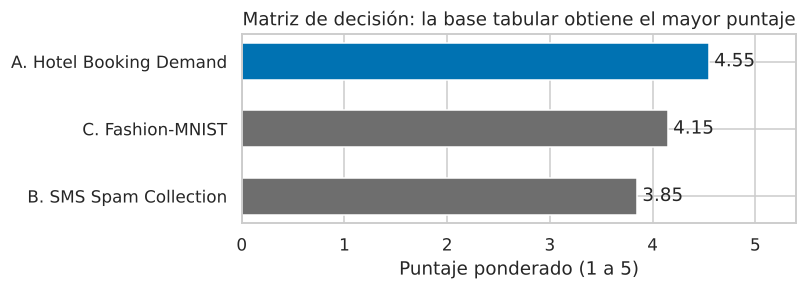

In [11]:
orden = puntajes.sort_values("Total ponderado")
fig, ax = plt.subplots(figsize=(7.5, 2.8))
barras = ax.barh(orden.index, orden["Total ponderado"], color=[GRIS, GRIS, AZUL], height=0.55)
for b in barras:
    ax.text(b.get_width() + 0.05, b.get_y() + b.get_height() / 2, f"{b.get_width():.2f}", va="center")
ax.set(xlim=(0, 5.4), xlabel="Puntaje ponderado (1 a 5)", title="Matriz de decisión: la base tabular obtiene el mayor puntaje")
plt.tight_layout()
plt.show()

### Decisión

**Escogimos la base A, Hotel Booking Demand (puntaje 4,55).**

- En completitud no es la mejor: es la única de las tres con faltantes y filas repetidas. Pero esos problemas son justamente los que nos permiten practicar la limpieza.
- En relevancia sí gana, porque es la única con la que podemos hacer las ocho tareas del proyecto. Tiene variables numéricas, categóricas con pocas categorías, categóricas con muchas (177 países) y fechas.
- Tiene buena documentación: un artículo publicado donde se define cada variable.
- Pesa 17 MB y carga en Colab en pocos segundos.

Las otras dos las descartamos por motivos distintos: con **SMS** tendríamos que usar técnicas de texto que no hemos visto, y **Fashion-MNIST** viene tan limpia que no hay nada que limpiar ni codificar.

**Pregunta que queremos responder en el resto del proyecto:** ¿qué características de una reserva se relacionan con que termine cancelada?

➡️ Continúa en `02_eda_calidad_univariado.ipynb`.